In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import os, re
import sklearn
import time
import string
import logomaker
import glob
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import adjusted_mutual_info_score as AMI
from matplotlib.patches import Patch
from pathlib import Path
from scipy import io
from helps import *
pd.set_option("display.precision", 12)
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli","bionSBM"])}

# Fig 3

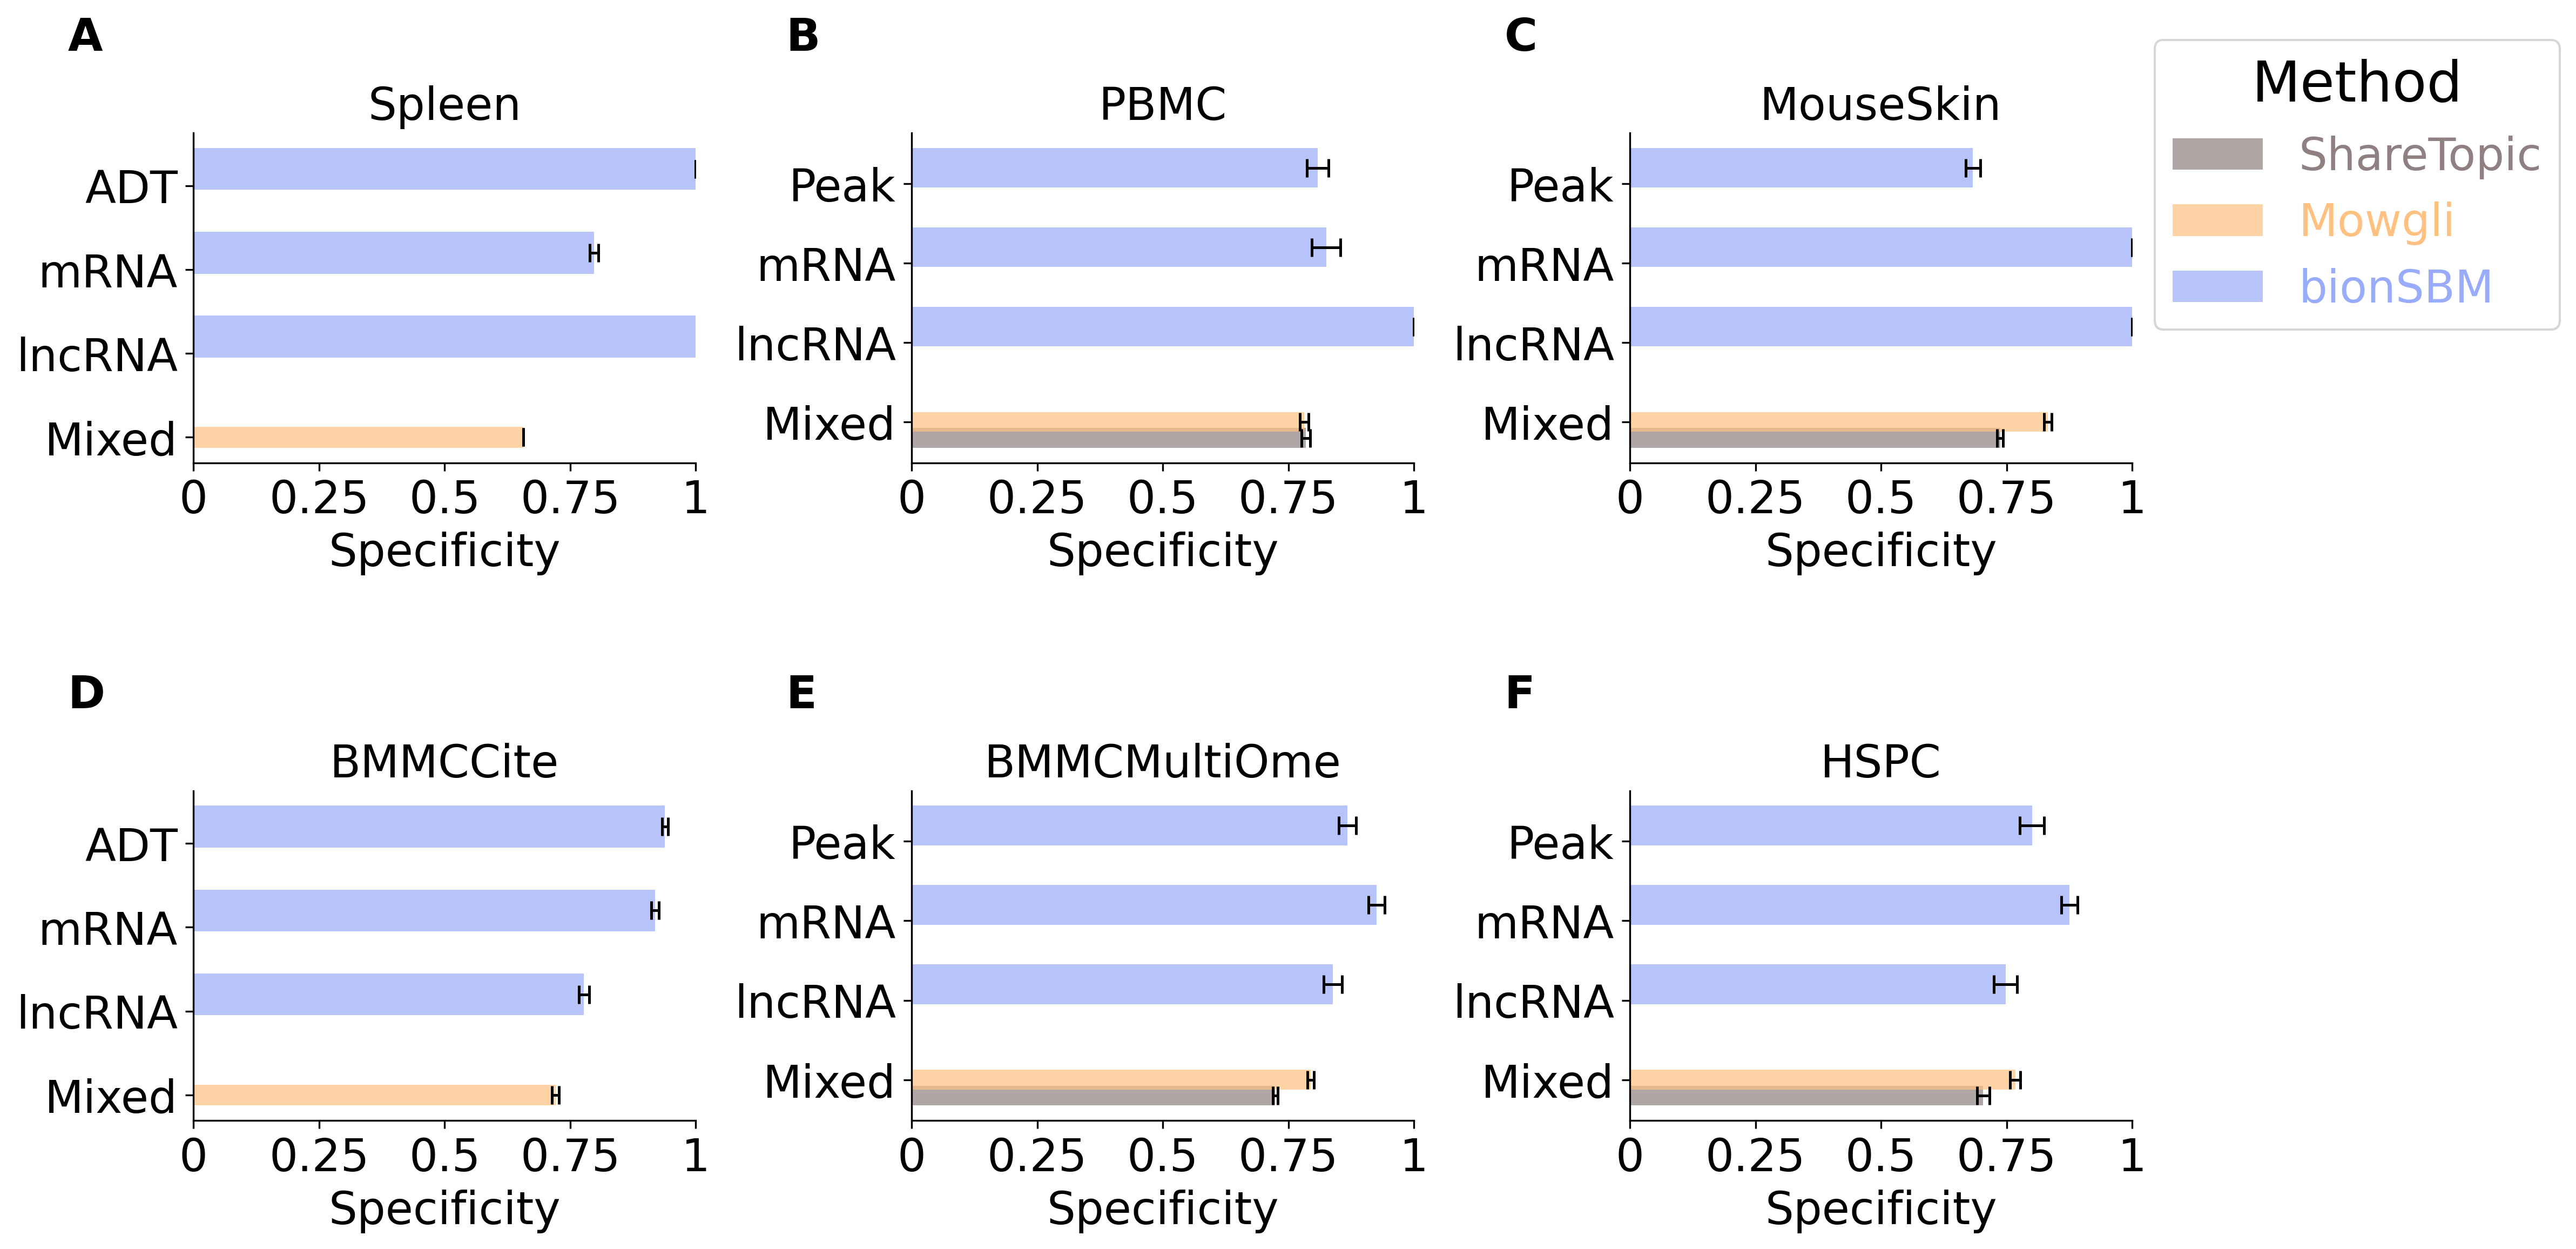

In [3]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 20,
         'ytick.labelsize': 20,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 8]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()


for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(dataset,exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
            "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)
    
    df["Specificty"] = df["DifferentTopics"] / df["NumberOfTopics"]

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Specificty"].mean()
        sems  = 3*d.groupby("FS")["Specificty"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions, means[fs_present], height=height,color=palette[meth], alpha=0.7, label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',
            ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)), range(len(order)), fontsize=20)

    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].set_xlabel("Specificity")
    axs[l].annotate(string.ascii_uppercase[l],xy=(-0.25, 1.25),xycoords='axes fraction',fontsize=20,fontweight="bold",ha='left')

handles, labels = axs[2].get_legend_handles_labels()
axs[2].legend(handles, labels,bbox_to_anchor=(1, 1.35), title="Method",fontsize=20,title_fontsize=25, labelcolor=palette.values())


fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/bionSBM_Fig3.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig 4

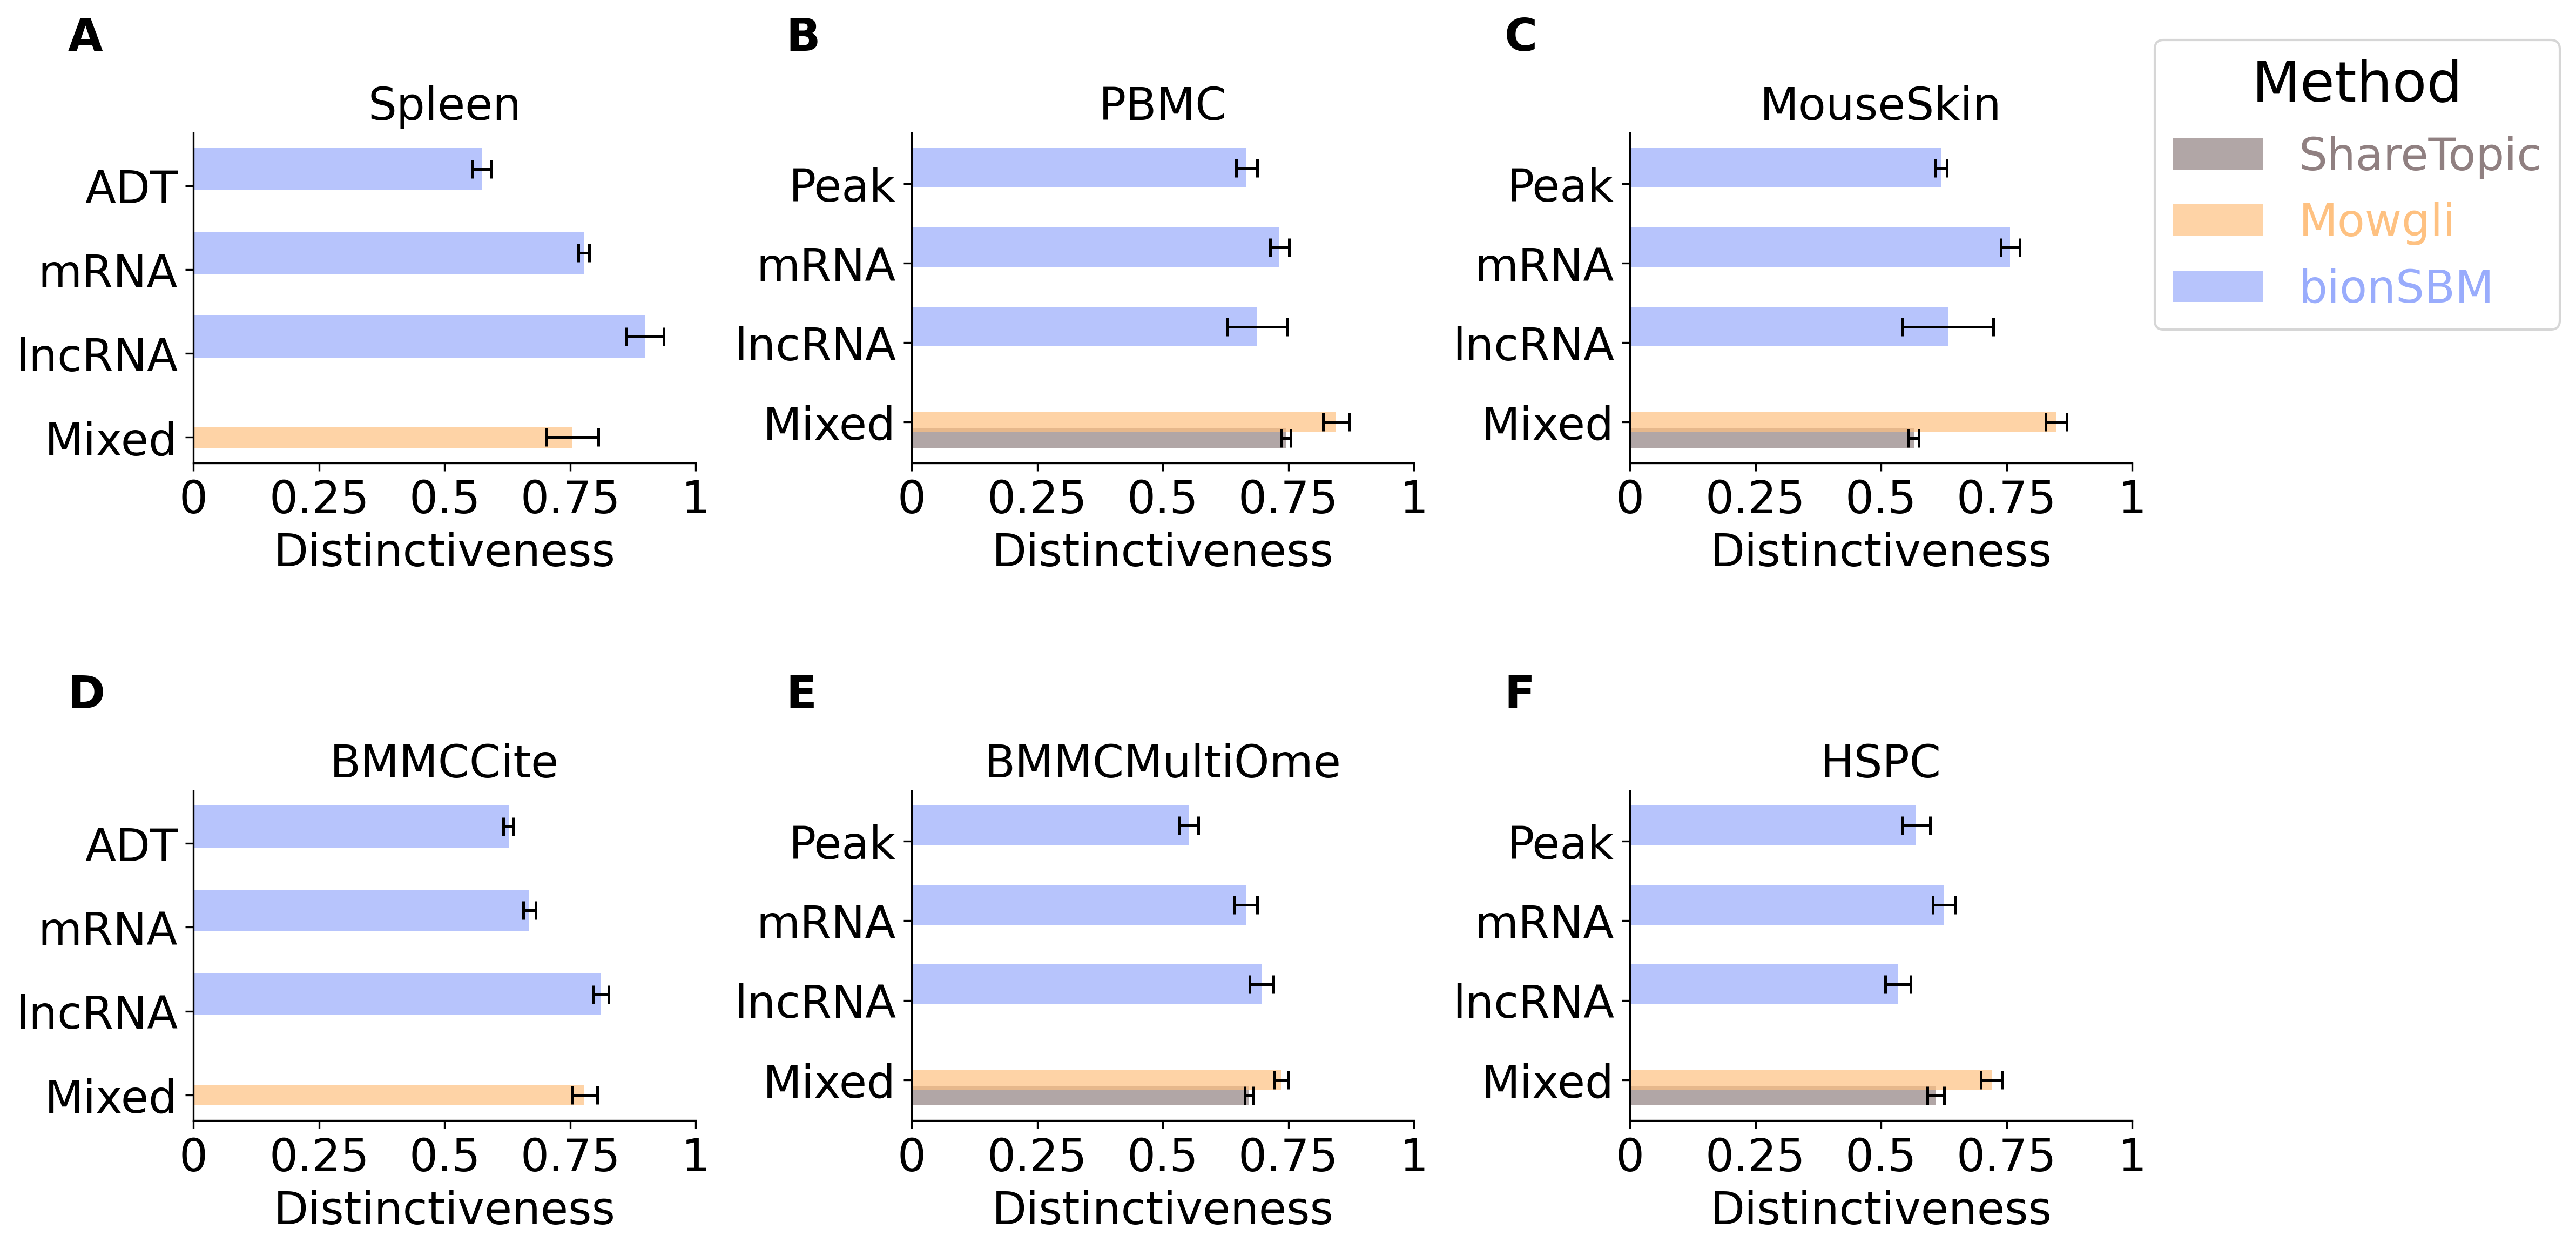

In [4]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 20,
         'ytick.labelsize': 20,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 8]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()

for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(
        dataset,
        exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
              "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Topics_distinctiveness"].mean()
        sems  = 3*d.groupby("FS")["Topics_distinctiveness"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions,means[fs_present],height=height,color=palette[meth],alpha=0.7,label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
        
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)))
    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].annotate(string.ascii_uppercase[l],xy=(-0.25, 1.25),xycoords='axes fraction',fontsize=20,fontweight="bold",ha='left')

handles, labels = axs[2].get_legend_handles_labels()
axs[2].legend(handles, labels,bbox_to_anchor=(1, 1.35), title="Method",fontsize=20,title_fontsize=25, labelcolor=palette.values())

for ax in axs:
    ax.set_xlabel("Distinctiveness")

fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/bionSBM_Fig4.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig 5

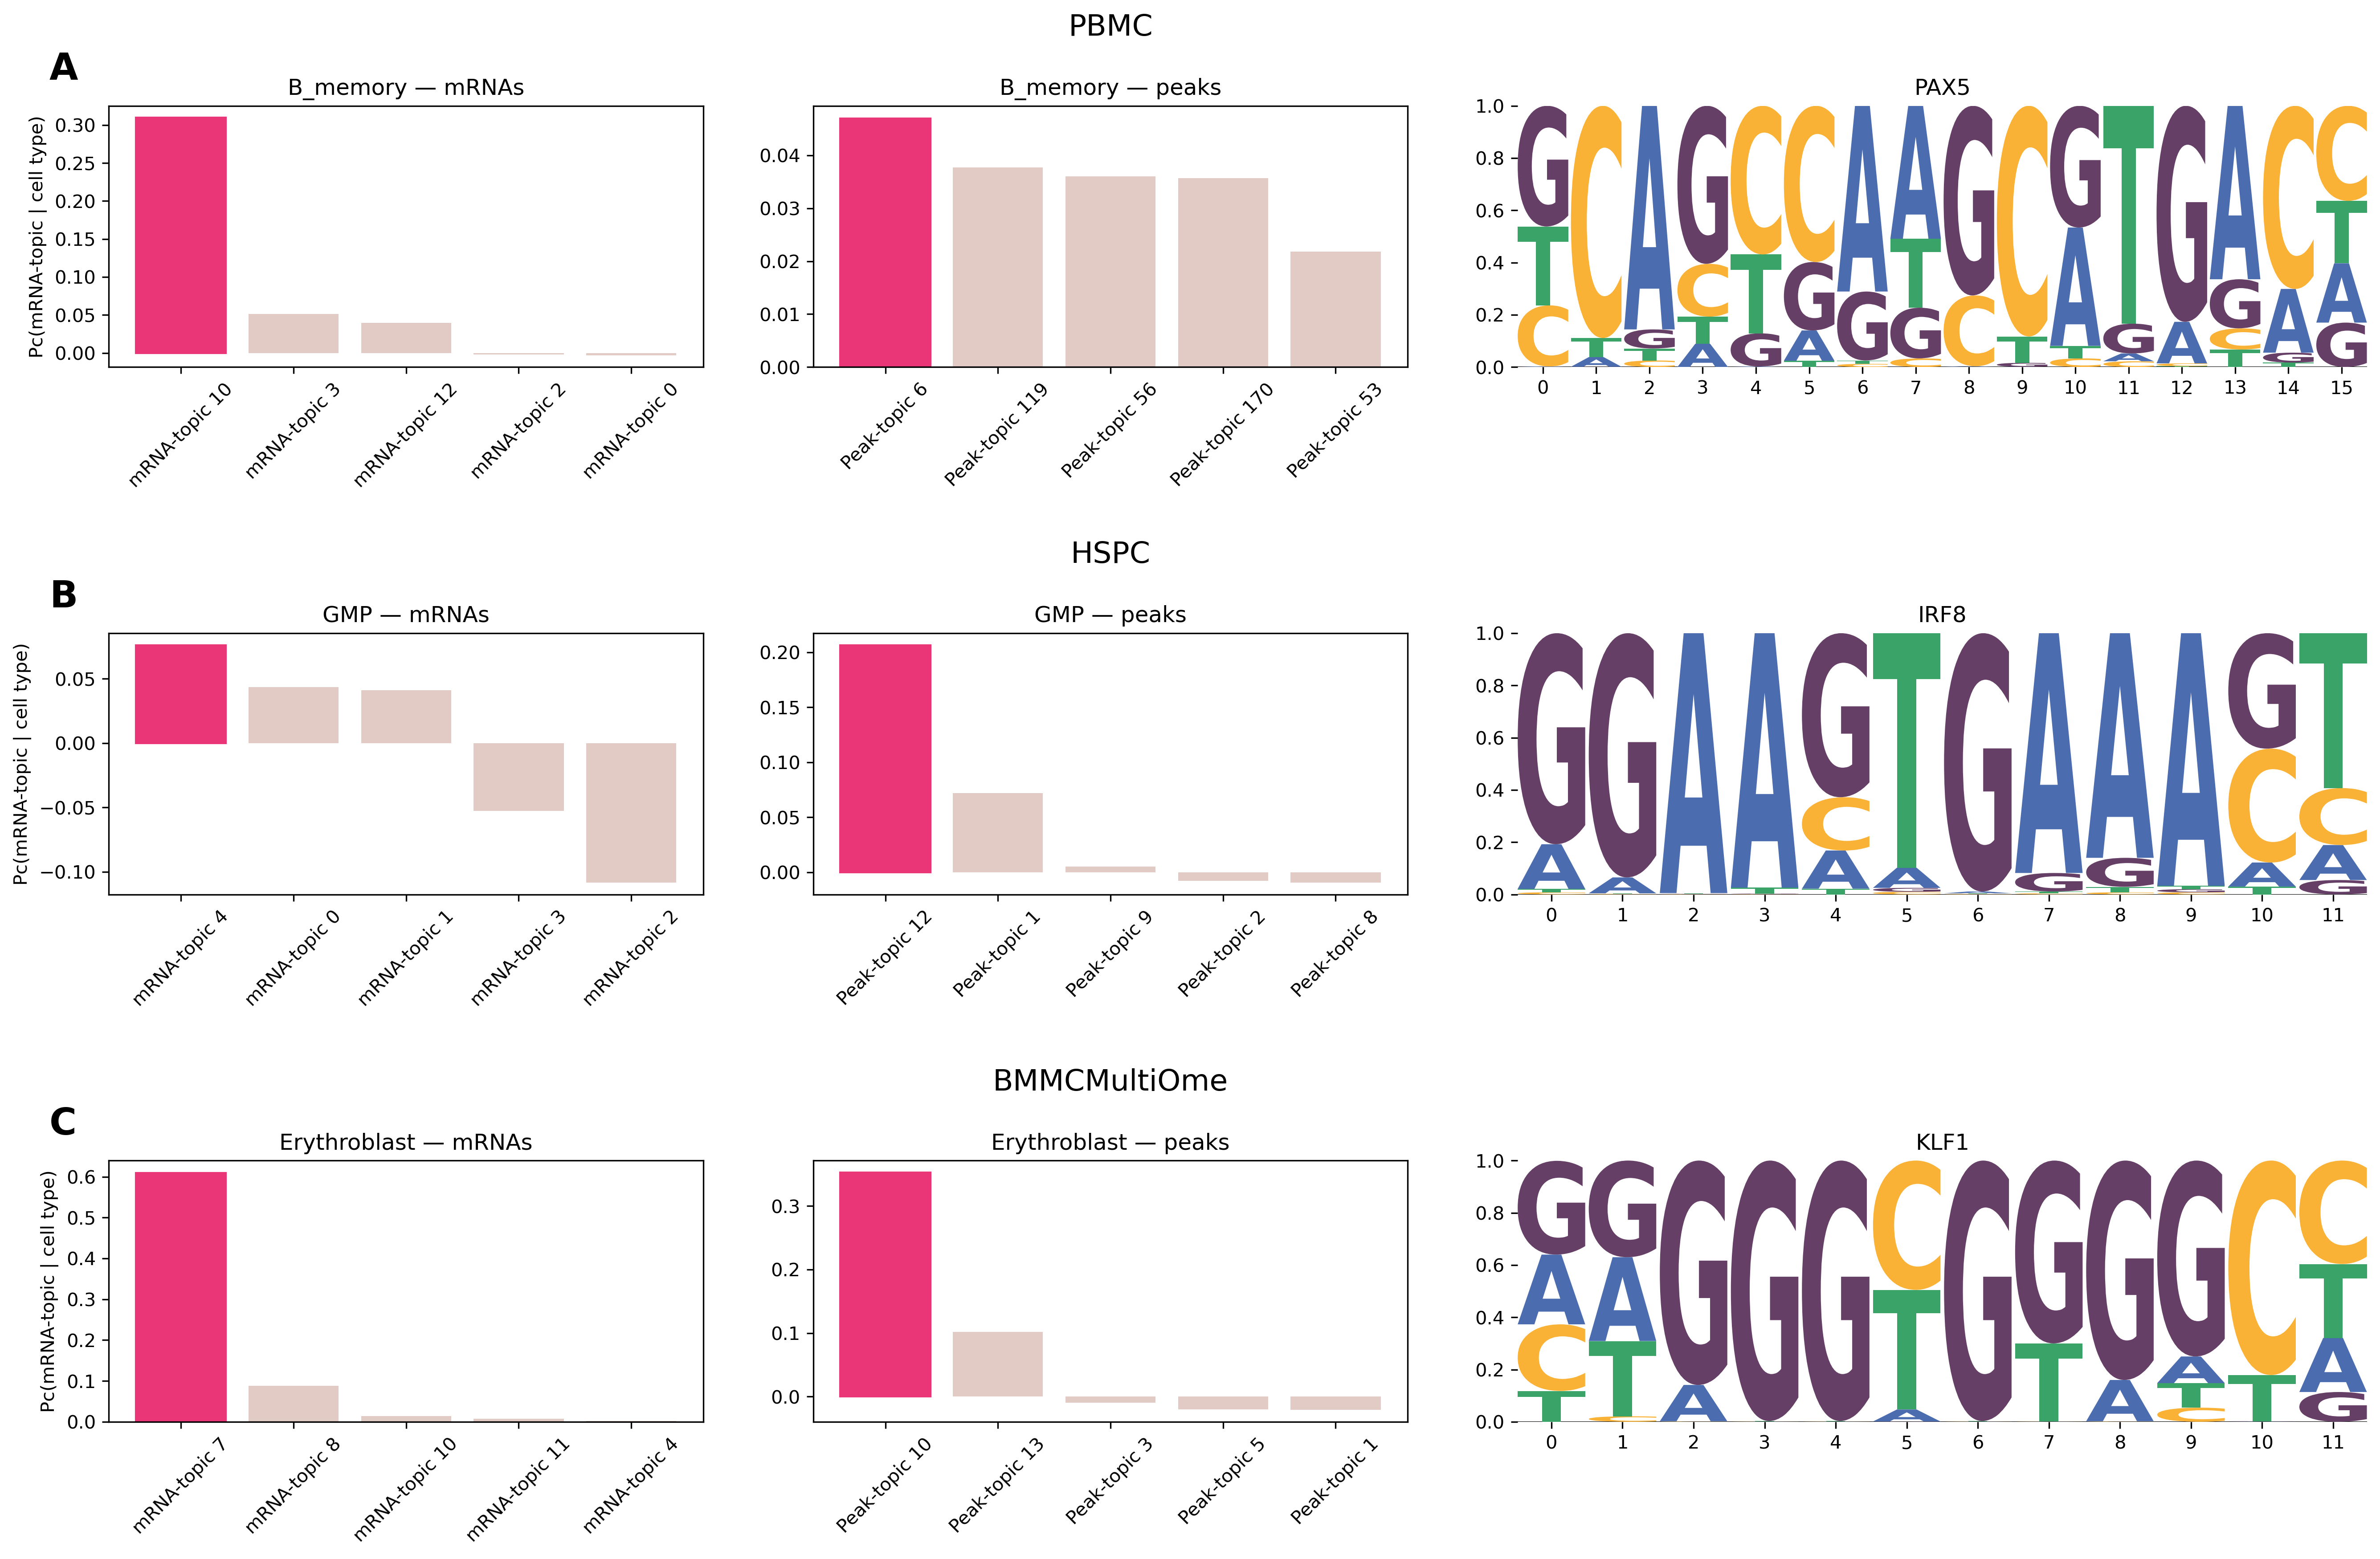

In [7]:
validation_df = pd.DataFrame([
    ["PBMC", "B_memory", "Topic 10", "Topic 6", "PAX5", 22, 0, "Top on both", 156, "Datasets/PBMC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run22/Topic_6/knownResults.html"],
    ["HSPC", "GMP", "Topic 4", "Topic 12", "IRF8", 5, 2, "-", 44, 'Datasets/HSPC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run5/Topic_12/knownResults.html'],
    ["BMMCMultiOme", "Erythroblast", "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3", 10, 'Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA_lncRNA/Run19/Topic_10/knownResults.html']],                              
    columns=["Dataset", "CellType", "mRNA-Topic", "Peak-topic", "Gene in mRNA-Topic", "Run", "Level", "Note", "Motif_Number", "Motif_HTML"])

# --------------------------------------------------
# Colors (already defined in your environment)
# --------------------------------------------------
dna_colors = {
    "A": colors_to_use[19],
    "C": colors_to_use[14],
    "G": colors_to_use[2],
    "T": colors_to_use[5]
}

BASE_COLOR = colors_to_use[11]
HIGHLIGHT_COLOR = colors_to_use[16]

top_n = 5
# ---------------------------------------------
# Create single 3x3 figure
# ---------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12), dpi=300, gridspec_kw={"width_ratios": [0.7, 0.7, 1]})

for i, (_, row) in enumerate(validation_df.iterrows()):

    dataset = row["Dataset"]
    run = int(row["Run"])
    level = int(row["Level"])

    mrna_topic_num = int(re.search(r"\d+", row["mRNA-Topic"]).group())
    peak_topic_num = int(re.search(r"\d+", row["Peak-topic"]).group())

    cell_type_to_plot=row["CellType"]

    # ---------------------------------------------
    # Load data (same logic as your function)
    # ---------------------------------------------
    metadata = pd.read_csv(
        f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz",
        sep="\t",
        index_col=0
    )

    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"

    mRNA_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_mRNA_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    Peak_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_Peak_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    # Normalize topic naming
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")

    # Align cells
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )

    metadata = metadata.loc[common_cells]
    mRNA_topics = mRNA_topics.loc[common_cells]
    Peak_topics = Peak_topics.loc[common_cells]

    # Center matrices (same as your logic)
    mRNA_centered = mRNA_topics - mRNA_topics.mean(axis=0)
    Peak_centered = Peak_topics - Peak_topics.mean(axis=0)

    # ---------------------------------------------
    # Compute enrichment for selected celltypes
    # ---------------------------------------------
    mask_ct = metadata["CellType"].isin([cell_type_to_plot])

    mrna_enrichment = mRNA_centered.loc[mask_ct].mean(axis=0)
    peak_enrichment = Peak_centered.loc[mask_ct].mean(axis=0)

    # Validated topic names
    mrna_topic_name = [c for c in mRNA_topics.columns if c.endswith(f"_{mrna_topic_num}")][0]
    peak_topic_name = [c for c in Peak_topics.columns if c.endswith(f"_{peak_topic_num}")][0]
    # Top N topics
    mrna_top = mrna_enrichment.sort_values(ascending=False).head(top_n)
    peak_top = peak_enrichment.sort_values(ascending=False).head(top_n)
    
    # ---------------------------------------------
    # Column 1 — mRNA
    # ---------------------------------------------
    ax_m = axes[i, 0]
    bars = ax_m.bar(range(len(mrna_top)), mrna_top.values, color=BASE_COLOR)

    if mrna_topic_name in mrna_top.index:
        idx = list(mrna_top.index).index(mrna_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_m.set_xticks(range(len(mrna_top)))
    ax_m.set_xticklabels(mrna_top.index.str.replace("A_t","A-t").str.replace("_"," "), rotation=45)
    ax_m.set_title(f"{cell_type_to_plot} — mRNAs")
    ax_m.set_ylabel("Pc(mRNA-topic | cell type)")
    ax_m.text(-0.1, 1.1, string.ascii_uppercase[i], transform=ax_m.transAxes, fontsize=20, fontweight='bold')
    
    # ---------------------------------------------
    # Column 2 — Peak
    # ---------------------------------------------
    ax_p = axes[i, 1]
    bars = ax_p.bar(range(len(peak_top)), peak_top.values, color=BASE_COLOR)

    if peak_topic_name in peak_top.index:
        idx = list(peak_top.index).index(peak_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_p.set_xticks(range(len(peak_top)))
    ax_p.set_xticklabels(peak_top.index.str.replace("k_t","k-t").str.replace("_"," "), rotation=45)
    ax_p.set_title(f"{cell_type_to_plot} — peaks")
    ax_p.text(0.5, 1.3, dataset, transform=ax_p.transAxes, fontsize=16, ha="center", va="center")
    # ---------------------------------------------
    # Column 3 — Motif Logo
    # ---------------------------------------------
    motif_number = row["Motif_Number"]
    if isinstance(motif_number, list):
        motif_number = motif_number[0]

    motif_path = (
        Path(f"Datasets/{dataset}/bionSBM/Motifs/"
             f"Peak_mRNA_lncRNA/Run{run}/"
             f"Topic_{peak_topic_num}/knownResults")
        / f"known{motif_number}.motif"
    )

    motif_df = pd.read_csv(motif_path, sep="\t", header=None, names=["A", "C", "G", "T"],skiprows=1)

    ax_logo = axes[i, 2]
    logo = logomaker.Logo(motif_df,ax=ax_logo,color_scheme=dna_colors)

    logo.style_spines(visible=False)
    logo.style_xticks(fmt='%d', anchor=0)

    ax_logo.set_title(row["Gene in mRNA-Topic"])
    ax_logo.set_ylabel("")

plt.tight_layout(w_pad=3)
plt.savefig(f"Figures/bionSBM_Fig5.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Extra

In [ ]:
validation_df = pd.DataFrame([
    ["PBMC", "B_memory; B_naive", "Topic 10", "Topic 6", "PAX5", 22, 0, "Top on both"],
    ["HSPC", "GMP", "Topic 4", "Topic 12", "IRF8", 5, 2, "-"],
    ["BMMCMultiOme", "Erythroblast; Proerythroblast; Normoblast", "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3"]
], 
                             
    columns=["Dataset", "CellType", "mRNA-Topic", "Peak-topic", "Gene in mRNA-Topic", "Run", "Level", "Note"])

def find_motif_info(row):
    
    dataset = row["Dataset"]
    run = row["Run"]
    peak_topic_num = int(re.search(r"\d+", row["Peak-topic"]).group())
    target_gene = row["Gene in mRNA-Topic"].upper()
    
    base_folder = (
        f"Datasets/{dataset}/bionSBM/Motifs/"
        f"Peak_mRNA_lncRNA/Run{run}/"
        f"Topic_{peak_topic_num}"
    )
    
    motif_file = os.path.join(base_folder, "knownResults.txt")
    html_file = os.path.join(base_folder, "knownResults.html")
    
    if not os.path.exists(motif_file):
        return pd.Series({
            "Motif_Number": None,
            "Motif_HTML": html_file
        })
    
    motif_df = pd.read_csv(motif_file, sep="\t")
    
    motif_numbers = []
    
    for idx, r in motif_df.iterrows():
        
        motif_number = idx + 1  # HOMER numbering
        
        if r["q-value (Benjamini)"] >= 0.05:
            continue
        
        motif_name = r["Motif Name"]
        raw_tf = re.search(r"^([^(/]+)", motif_name)
        
        if raw_tf:
            tf = raw_tf.group(1).upper()
            parts = [p.strip() for p in re.split(r"[:/]", tf)]
            
            if target_gene in parts:
                motif_numbers.append(motif_number)
    
    return pd.Series({
        "Motif_Number": motif_numbers if motif_numbers else None,
        "Motif_HTML": html_file
    })
validation_df[["Motif_Number", "Motif_HTML"]] = (
    validation_df.apply(find_motif_info, axis=1)
)
validation_df

In [ ]:
def plot_dataset(dataset="PBMC", run=22, selected_level=0, top_n=20, cell_types_to_plot=["B_memory","B_naive"]):
    # Define the cell types you want to plot
    metadata = pd.read_csv(
        f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz",
        sep="\t",
        index_col=0
    )
    
    CellTypes = metadata["CellType"].unique()
    n_celltypes = len(CellTypes)
    
    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"
    mRNA_path = os.path.join(
        base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{selected_level}_mRNA_topics_documents.tsv.gz"
    )
    
    Peak_path = os.path.join(
        base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{selected_level}_Peak_topics_documents.tsv.gz"
    )
    
    mRNA_topics = pd.read_csv(mRNA_path, sep="\t", index_col=0)
    Peak_topics = pd.read_csv(Peak_path, sep="\t", index_col=0)
    
    # Normalize topic naming
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")
    
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )
    
    metadata = metadata.loc[common_cells]
    mRNA_topics = mRNA_topics.loc[common_cells]
    Peak_topics = Peak_topics.loc[common_cells]
    
    # Center matrices
    mRNA_centered = mRNA_topics - mRNA_topics.mean(axis=0)
    Peak_centered = Peak_topics - Peak_topics.mean(axis=0)
    
    def top_with_selected(series, selected, n):
        sorted_series = series.sort_values(ascending=False)
        top = sorted_series.head(n)
        if selected not in top.index:
            top = pd.concat([top, sorted_series.loc[[selected]]])
        return top
    
    
    n_rows = len(cell_types_to_plot)
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5*n_rows), dpi=200)
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    
    for i, cell_type in enumerate(cell_types_to_plot):
    
        print("Plotting:", cell_type)
    
        mask_ct = metadata["CellType"] == cell_type
    
        mrna_enrichment = mRNA_centered.loc[mask_ct].mean(axis=0)
        peak_enrichment = Peak_centered.loc[mask_ct].mean(axis=0)
    
        mrna_best = mrna_enrichment.idxmax()
        peak_best = peak_enrichment.idxmax()
    
        mrna_top = top_with_selected(mrna_enrichment, mrna_best, top_n)
        peak_top = top_with_selected(peak_enrichment, peak_best, top_n)
    
        # ---- mRNA panel ----
        ax_m = axes[i, 0]
        bars = ax_m.bar(range(len(mrna_top)), mrna_top.values)
        bars[list(mrna_top.index).index(mrna_best)].set_color("red")
    
        ax_m.set_xticks(range(len(mrna_top)))
        ax_m.set_xticklabels(mrna_top.index, rotation=90)
        ax_m.axhline(0, linestyle="--")
        ax_m.set_title(f"Run {run} — mRNA — {cell_type}")
        ax_m.set_ylabel("Mean Centered P(topic | CellType)")
    
        # ---- Peak panel ----
        ax_p = axes[i, 1]
        bars = ax_p.bar(range(len(peak_top)), peak_top.values)
        bars[list(peak_top.index).index(peak_best)].set_color("red")
    
        ax_p.set_xticks(range(len(peak_top)))
        ax_p.set_xticklabels(peak_top.index, rotation=90)
        ax_p.axhline(0, linestyle="--")
        ax_p.set_title(f"Run {run} — Peak — {cell_type}")
    
    plt.tight_layout()
    plt.show()

In [ ]:
dataset = "MouseSkin"  # change as needed
results_runs={}
metadata = pd.read_csv(f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz", sep="\t", index_col=0)
CellTypes = metadata["CellType"].unique()
n_celltypes = len(CellTypes)
print("Number of cell types:", n_celltypes)
for run in range(0,25):    
   
    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"
    
    levels = []
    cluster_counts = []
    
    for file in sorted(glob.glob(os.path.join(base_path, "*_clusters.tsv.gz"))):
        level = int(file.split("_level_")[1].split("_")[0])
        df = pd.read_csv(file, sep="\t", index_col=0)
        n_clusters = df.shape[0]  # number of cluster columns
        levels.append(level)
        cluster_counts.append(n_clusters)
    
    level_df = pd.DataFrame({
        "level": levels,
        "n_clusters": cluster_counts
    })
    
    level_df["diff"] = np.abs(level_df["n_clusters"] - n_celltypes)
    selected_level = level_df.sort_values("diff").iloc[0]["level"]
    #selected_level=1
    
    mRNA_path = os.path.join(
        base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{selected_level}_mRNA_topics_documents.tsv.gz"
    )
    
    Peak_path = os.path.join(
        base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{selected_level}_Peak_topics_documents.tsv.gz"
    )
    
    mRNA_topics = pd.read_csv(mRNA_path, sep="\t", index_col=0)#.replace(0, np.nan)
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    # Compute global mean per topic
    mRNA_global_mean = mRNA_topics.mean(axis=0)
    mRNA_topics_centered = mRNA_topics - mRNA_global_mean
    
    # Center P(topic | cell)
    Peak_topics = pd.read_csv(Peak_path, sep="\t", index_col=0)#.replace(0, np.nan)
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")
    Peak_global_mean = Peak_topics.mean(axis=0)
    Peak_topics_centered = Peak_topics - Peak_global_mean
    
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )
    metadata = metadata.loc[common_cells]
    mRNA_topics_centered = mRNA_topics_centered.loc[common_cells]
    Peak_topics_centered = Peak_topics_centered.loc[common_cells]
    
    def compute_enrichment(topic_df, metadata, celltype_col="CellType"):
        results = []
    
        for ct in metadata[celltype_col].unique():
            mask_ct = metadata[celltype_col] == ct
            mask_other = ~mask_ct
    
            mean_ct = topic_df[mask_ct].mean(axis=0)
            mean_other = topic_df[mask_other].mean(axis=0)
    
            delta = mean_ct - mean_other
    
            best_topic = delta.idxmax()
            best_score = delta.max()
    
            results.append({
                "CellType": ct,
                "best_topic": best_topic,
                "delta": best_score
            })
    
        return pd.DataFrame(results)
    mRNA_best = compute_enrichment(mRNA_topics_centered, metadata)
    Peak_best = compute_enrichment(Peak_topics_centered, metadata)
    
    mRNA_best["modality"] = "mRNA"
    Peak_best["modality"] = "Peak"
    
    final_results = pd.concat([mRNA_best, Peak_best], ignore_index=True)
    
    motif_base = f"Datasets/{dataset}/bionSBM/Motifs/Peak_mRNA_lncRNA/Run{run}"
    mrna_topic_file = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}/bionSBM_Peak_mRNA_lncRNA_level_{selected_level}_mRNA_topics.tsv.gz"
    
    # Load mRNA topic-gene matrix
    mrna_topics_genes = pd.read_csv(mrna_topic_file, sep="\t", index_col=0)
    mrna_topics_genes.index = mrna_topics_genes.index.str.replace("#", "", regex=False)
    
    rows = []
    
    for cell_type in final_results["CellType"].unique():
    
        mrna_topic = final_results[
            (final_results["CellType"] == cell_type) &
            (final_results["modality"] == "mRNA")
        ]["best_topic"].values[0]
    
        peak_topic = final_results[
            (final_results["CellType"] == cell_type) &
            (final_results["modality"] == "Peak")
        ]["best_topic"].values[0]
    
        # -------------------------------------------------
        # 1️⃣ Get genes in mRNA topic (prob > 0)
        # -------------------------------------------------
        genes_mrna = set(mrna_topics_genes.index[mrna_topics_genes[mrna_topic] > 0])
    
        # -------------------------------------------------
        # 2️⃣ Read motif results (if folder exists)
        # -------------------------------------------------
        topic_num = int(re.search(r"\d+", peak_topic).group())
        motif_file = os.path.join(motif_base,f"Topic_{topic_num}","knownResults.txt")
    
        genes_peak = set()
    
        if os.path.exists(motif_file):
    
            motif_df = pd.read_csv(motif_file, sep="\t")
    
            # Keep significant motifs
            motif_df = motif_df[motif_df["q-value (Benjamini)"] < 0.05]
    
            # Extract TF names from "Motif Name"
            raw_tf = motif_df["Motif Name"].str.extract(r"^([^(/]+)")[0]
    
            # Normalize: uppercase and split composite names
            tf_names = set()
    
            for tf in raw_tf.dropna():
                if dataset != "MouseSkin":
                    tf = tf.upper()
                for part in re.split(r"[:/]", tf):
                    part = part.strip()
                    if part:
                        tf_names.add(part)
    
            genes_peak = tf_names
    
        # -------------------------------------------------
        # 3️⃣ Intersection
        # -------------------------------------------------
        intersect_genes = sorted(genes_mrna.intersection(genes_peak))
    
        # -------------------------------------------------
        # 4️⃣ Store result row
        # -------------------------------------------------
        row_dict = {
            "CellType": cell_type,
            "Run": run,
            "Level": selected_level,
            "mRNA_topic": mrna_topic,
            "Peak_topic": peak_topic,
        }
    
        for i, g in enumerate(intersect_genes):
            row_dict[f"Gene_{i+1}"] = g
    
        rows.append(row_dict)
    
    
    # -------------------------------------------------
    # Final dataframe
    # -------------------------------------------------
    final_gene_df = pd.DataFrame(rows)
    print("Selected level:", selected_level, "--- Run", run, "---Number of genes:", final_gene_df.shape[1]-5, 
          "---Number of mRNA-Topics:", mRNA_topics_centered.shape[1], "---Number of Peak-Topics:", Peak_topics_centered.shape[1])
    
    results_runs[f"Run{run}"]=final_gene_df

#def run_with_most_genes(diz):
#    return np.argmax([diz[key].shape[1] for key in diz.keys()])
#print("Best run:", run_with_most_genes(results_runs))
#results_runs[f"Run{run_with_most_genes(results_runs)}"]
df = results_runs["Run5"]
genes = (df[df["CellType"] == "GMP"].filter(like="Gene_").values.flatten())
[g for g in genes if pd.notna(g)]

In [ ]:
plot_dataset(dataset="PBMC", run=22, selected_level=0, top_n=5, cell_types_to_plot=["B_memory","B_naive"])
plot_dataset(dataset="HSPC", run=5, selected_level=2, top_n=5, cell_types_to_plot=["GMP"])
plot_dataset(dataset="BMMCMultiOme", run=19, selected_level=3, top_n=20, cell_types_to_plot=["Normoblast","Erythroblast","Proerythroblast"])